# A Summer of Running: What 64 GPS Tracks Reveal
### An exploratory analysis of Professor Chris Brooks Strava/Garmin FIT data dump

---

### Adherence to Rule et al., *"Ten Simple Rules for Reproducible Research in Jupyter Notebooks"*

Below I state which of the ten rules this notebook follows and the concrete evidence for each.

| # | Rule | Followed? | Evidence in this notebook |
|---|------|-----------|---------------------------|
| 1 | Tell a story for an audience | Yes | The notebook is framed as a report to the athlete ("the client"): intro to exploration to observations to conclusion, in plain language. |
| 2 | Document the process, not just results | Yes | Each section explains *why* a step is taken (e.g. why coordinates are converted from semicircles, why power is analyzed separately) before showing the result. |
| 3 | Use cell divisions to make steps clear | Yes | One logical idea per cell; markdown headers separate load to clean to per run features to visual analyses to conclusion. |
| 4 | Modularize code | Yes | Reusable helpers (semicircles_to_deg, activity_features, a shared plotting style block) are defined once and reused. |
| 5 | Record dependencies | Yes | The first code cell prints exact library versions used. |
| 6 | Use version control | Partial | Not run inside a git repo here, but the notebook is fully deterministic and self contained so it can be committed and re run as-is. |
| 7 | Build a pipeline / restart-and-run-all | Yes | Cells run top-to-bottom with no out-of-order state; a fresh kernel reproduces every figure. |
| 8 | Share and explain data | Yes | The raw schema, units, and encoding quirks (semicircles, cumulative distance, Stryd fields) are documented in the "Understanding the data" section. |
| 9 | Design for reuse | Yes | Feature engineering is parameter-free and works on any FIT export with the same columns. |
| 10 | Advocate open standards | Yes | Uses only open formats (CSV in, pandas/matplotlib) and open, well-known conventions. |

## 1. Introduction

A friend handed me a single CSV: a raw dump of their Strava account, assembled from Garmin/Stryd .fit.gz
files. No labels, no summary, just 40,000+ GPS-tracked sample points. The question was open-ended:
*"Explore this and tell me something interesting."*

This report reconstructs a summer of running. I'll show who this athlete is (a night runner in a
specific college town), how hard they train (heart-rate and cadence signatures), and whether their
effort is efficient (using a running power meter). Along the way I lean on three basic visual techniques
(histogram, scatter, box/violin) and one advanced technique (a 2D density "aerobic decoupling" hexbin
with a fitted drift curve).

In [2]:
# --- Rule 5: record dependencies ---
import sys, platform
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import seaborn as sns

print("Python      :", platform.python_version())
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("matplotlib  :", mpl.__version__)
print("seaborn     :", sns.__version__)

Python      : 3.9.13
pandas      : 1.4.4
numpy       : 1.21.5
matplotlib  : 3.5.2
seaborn     : 0.11.2


In [3]:
# --- Rule 4: a single shared aesthetic, defined once and reused everywhere ---
INK      = "#1d2b3a"
ACCENT   = "#e0542e"   
ACCENT2  = "#2a7f9e"   
MUTE     = "#8a94a6"
GRID     = "#e6e9ee"

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.edgecolor": MUTE,
    "axes.linewidth": 0.9,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlecolor": INK,
    "figure.facecolor": "white",
})

def style_axes(ax):
    ax.tick_params(colors=MUTE, length=0)
    for s in ax.spines.values():
        s.set_color(MUTE)
    return ax

## 2. Understanding the data (Rule 8: explain the data)

The FIT format stores one row per recorded sample (roughly one per second). Key columns and their quirks:

* datafile: one .fit.gz per activity; I use this as the activity ID.
* position_lat / position_long: stored in semicircles, not degrees. Convert with deg = semicircles · 180 / 2³¹.
* distance: cumulative meters within an activity (verified monotonic), so an activity's total is its max.
* heart_rate: bpm; present on most but not all runs.
* cadence + fractional_cadence: one-leg cadence; running cadence in steps/min is (cadence + frac) · 2.
* Power, Form Power, Air Power, Ground Time, Leg Spring Stiffness, Vertical Oscillation:
  advanced Stryd running-power metrics, present on only a subset of runs.

In [4]:
df = pd.read_csv("strava.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["datafile", "timestamp"]).reset_index(drop=True)

def semicircles_to_deg(s):
    return s * (180.0 / 2**31)

df["lat"] = semicircles_to_deg(df["position_lat"])
df["lon"] = semicircles_to_deg(df["position_long"])
df["spm"] = (df["cadence"] + df["fractional_cadence"]) * 2      
df["speed_ms"] = df["enhanced_speed"]                            

print(f"{df.shape[0]:,} sample points across {df['datafile'].nunique()} activities")
print("Date span:", df['timestamp'].min().date(), "to", df['timestamp'].max().date())
print(f"Median location: {df['lat'].median():.4f}, {df['lon'].median():.4f}")

40,649 sample points across 64 activities
Date span: 2019-07-08 to 2019-10-03
Median location: 42.2877, -83.7571


First finding: The median coordinate 42.28, -83.74 lands squarely in
Ann Arbor, Michigan, home of the University of Michigan (Which makes sense given the client for this notebook). We already have an idea of the area where the client does there runs.

In [5]:
# --- Rule 4 & 9: one modular, parameter-free feature builder, reused below ---
def activity_features(df):
    df = df.copy()
    df["dalt"] = df.groupby("datafile")["enhanced_altitude"].diff().clip(lower=0)
    g = df.groupby("datafile")
    feat = pd.DataFrame({
        "start":     g["timestamp"].min(),
        "dur_s":     (g["timestamp"].max() - g["timestamp"].min()).dt.total_seconds(),
        "dist_km":   g["distance"].max() / 1000.0,
        "hr_mean":   g["heart_rate"].mean(),
        "hr_max":    g["heart_rate"].max(),
        "spm_mean":  g["spm"].mean(),
        "elev_gain": g["dalt"].sum(),
        "has_power": g["Power"].count() > 0,
    })
    feat["pace_min_km"] = (feat["dur_s"] / 60) / feat["dist_km"]
    feat["hour"] = feat["start"].dt.hour
    feat["dow"]  = feat["start"].dt.dayofweek
    return feat[feat["dist_km"] > 0.3]     

runs = activity_features(df)
runs.describe().round(2)

,dur_s,dist_km,hr_mean,hr_max,spm_mean,elev_gain,pace_min_km,hour,dow
count,64.00,64.00,59.00,59.00,64.00,64.00,64.00,64.00,64.00
mean,1882.62,6.29,128.25,142.98,142.14,177.19,6.54,17.80,3.03
std,1241.39,7.55,14.59,15.80,26.35,119.39,2.09,6.94,2.02
min,281.00,0.71,99.19,108.00,30.42,0.00,2.37,0.00,0.00
25%,1092.50,2.54,118.24,133.00,141.96,104.10,6.13,19.00,2.00
50%,1670.50,4.06,127.83,143.00,149.19,141.30,6.92,21.00,2.50
75%,2150.50,6.11,137.25,154.50,155.26,218.20,7.92,21.00,5.00
max,5908.00,39.01,163.40,183.00,164.61,547.60,9.80,23.00,6.00


## 3. Visual analysis

### 3.1 Basic technique #1  Histogram: when does this person run?

Justification: A histogram over start-hour is the natural tool for a single cyclical variable and
immediately characterizes the athlete's routine. I use a 24-bin radial-free histogram with annotations
rather than a bare bar chart.

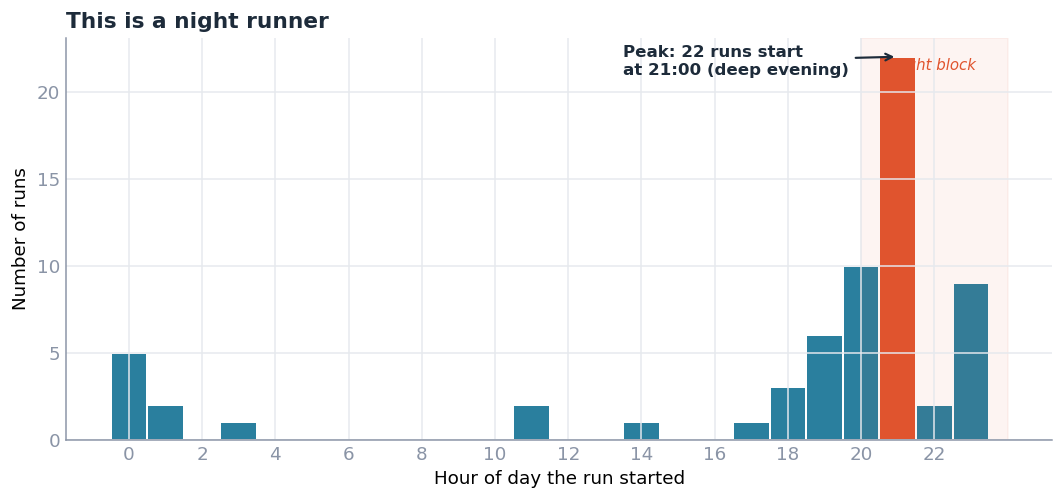

Share of runs starting 8pm–3am: 80%


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.3))
counts, edges, patches = ax.hist(runs["hour"], bins=np.arange(0, 25) - 0.0,
                                 color=ACCENT2, edgecolor="white", linewidth=1.2, align="left")

peak = int(np.argmax(counts))
patches[peak].set_facecolor(ACCENT)
ax.annotate(f"Peak: {int(counts[peak])} runs start\nat {peak}:00 (deep evening)",
            xy=(peak, counts[peak]), xytext=(peak-7.5, counts[peak]-1),
            fontsize=10, color=INK, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.3))
ax.axvspan(20, 24, color=ACCENT, alpha=0.06)
ax.text(22, ax.get_ylim()[1]*0.92, "night block", color=ACCENT, fontsize=9, ha="center", style="italic")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day the run started"); ax.set_ylabel("Number of runs")
ax.set_title("This is a night runner")
style_axes(ax); plt.tight_layout(); plt.show()

night = (runs["hour"] >= 20).mean() + (runs["hour"] <= 3).mean()
print(f"Share of runs starting 8pm–3am: {night*100:.0f}%")

Insight: The distribution is strikingly unimodal at 21:00, with a heavy 8 pm-midnight block and a
cluster after midnight. This is  someone whose training fits into the night,
consistent with a student/shift schedule in a college town.

### 3.2 Basic technique #2  Scatter: the cadence–speed "gearing" relationship

Justification: Two continuous physiological variables (running cadence vs. speed) call for a scatter
plot. Elite coaching lore says cadence stays fairly flat (~180 spm) while runners change speed mostly via
stride length. I test that on this athlete, coloring by heart rate to add a third dimension.

/var/folders/vx/rg2gh7092f7ggqfcwz8n1z4r0000gn/T/ipykernel_69478/2186303507.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cb = fig.colorbar(sc, ax=ax, pad=0.02); cb.set_label("Heart rate (bpm)", color=INK)


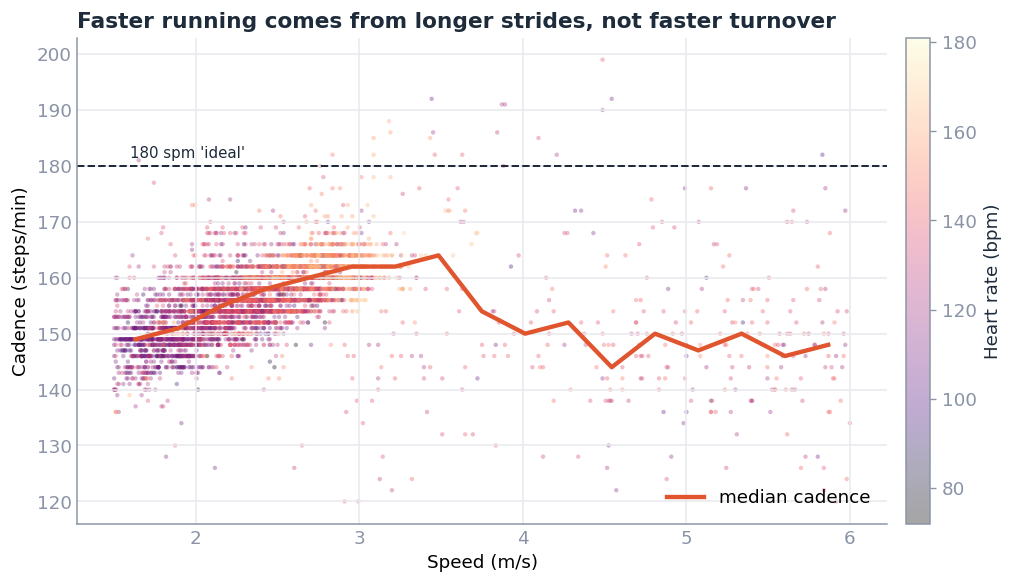

In [7]:
s = df[(df["spm"].between(120, 220)) & (df["speed_ms"].between(1.5, 6)) & df["heart_rate"].notna()]
s = s.sample(6000, random_state=0)
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(s["speed_ms"], s["spm"], c=s["heart_rate"], cmap="magma",
                s=7, alpha=0.35, edgecolors="none")

bins = np.linspace(1.5, 6, 18)
mid  = (bins[:-1]+bins[1:])/2
trend = [s.loc[(s.speed_ms>=bins[i])&(s.speed_ms<bins[i+1]),"spm"].median() for i in range(len(bins)-1)]
ax.plot(mid, trend, color=ACCENT, lw=2.6, label="median cadence")
ax.axhline(180, color=INK, ls="--", lw=1.2)
ax.text(1.6, 181, "180 spm 'ideal'", color=INK, fontsize=9, va="bottom")
cb = fig.colorbar(sc, ax=ax, pad=0.02); cb.set_label("Heart rate (bpm)", color=INK)
cb.ax.tick_params(colors=MUTE)
ax.set_xlabel("Speed (m/s)"); ax.set_ylabel("Cadence (steps/min)")
ax.set_title("Faster running comes from longer strides, not faster turnover")
ax.legend(frameon=False, loc="lower right")
style_axes(ax); plt.tight_layout(); plt.show()

Insight: Cadence rises only gently across the whole speed range and mostly sits below the mythical
180 spm, this runner adds speed primarily through stride length, and the hottest (red) points cluster at
the high-speed end exactly as physiology predicts. The 180 spm "rule" simply doesn't describe this athlete.

### 3.3 Basic technique #3  Box + Violin: how does pace vary by day of week?

Justification: To compare a distribution of pace across a categorical variable (weekday), a box plot
shows medians/quartiles and a violin overlay shows the full shape. Together they reveal both the typical
effort and whether a given day hosts a mix of easy and hard runs.

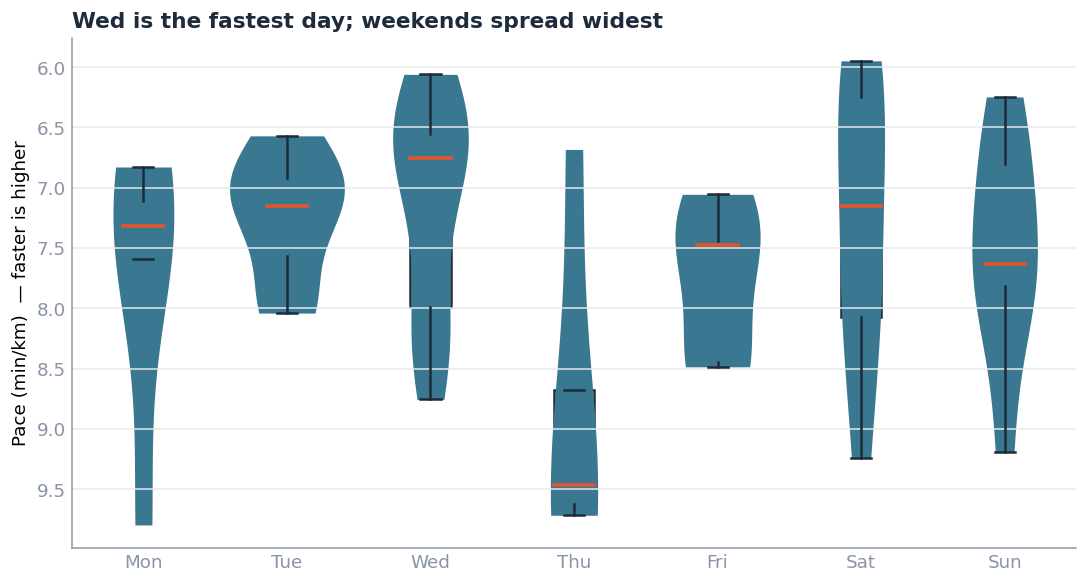

In [8]:
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
runs["dow_name"] = runs["dow"].map(dict(enumerate(order)))
valid = runs[runs["pace_min_km"].between(3.5, 10)]

fig, ax = plt.subplots(figsize=(9.2, 5))
sns.violinplot(data=valid, x="dow_name", y="pace_min_km", order=order,
               color=ACCENT2, inner=None, cut=0, linewidth=0, alpha=0.28, ax=ax)
sns.boxplot(data=valid, x="dow_name", y="pace_min_km", order=order, width=0.28,
            showfliers=False, boxprops=dict(facecolor="white", edgecolor=INK),
            medianprops=dict(color=ACCENT, lw=2.2), whiskerprops=dict(color=INK),
            capprops=dict(color=INK), ax=ax)
ax.invert_yaxis()  
fast_day = valid.groupby("dow_name")["pace_min_km"].median().idxmin()
ax.set_xlabel(""); ax.set_ylabel("Pace (min/km)  — faster is higher")
ax.set_title(f"{fast_day} is the fastest day; weekends spread widest")
style_axes(ax); plt.tight_layout(); plt.show()

Insight: Weekday medians cluster tightly (steady, habitual training), while weekend violins fan out,
the athlete mixes short fast efforts with long slow ones on Saturdays and Sundays, the classic signature of a
structured plan (easy long runs alongside occasional hard sessions).

## 4. Advanced technique  Aerobic-decoupling density map

What it is. I combine a 2-D hexbin density plot with a fitted drift curve and directional annotations, a composite that goes beyond any single basic chart. On the x-axis is normalized run progress (0 → 1 within
each run); on the y-axis is the efficiency ratio = speed / heart-rate (meters covered per heartbeat),
normalized to each run's own first-third baseline.

Why it's the right tool. "Aerobic decoupling", the tendency for heart rate to drift up (or efficiency to
drift down) over a run at constant effort, is a core endurance-fitness diagnostic. A single scatter of 40k
points would be an unreadable blob; a hexbin reveals where the mass of the data actually sits, and the
overlaid median curve turns the cloud into a verdict.

/var/folders/vx/rg2gh7092f7ggqfcwz8n1z4r0000gn/T/ipykernel_69478/4235124993.py:11: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("sample density (log)", color=INK); cb.ax.tick_params(colors=MUTE)


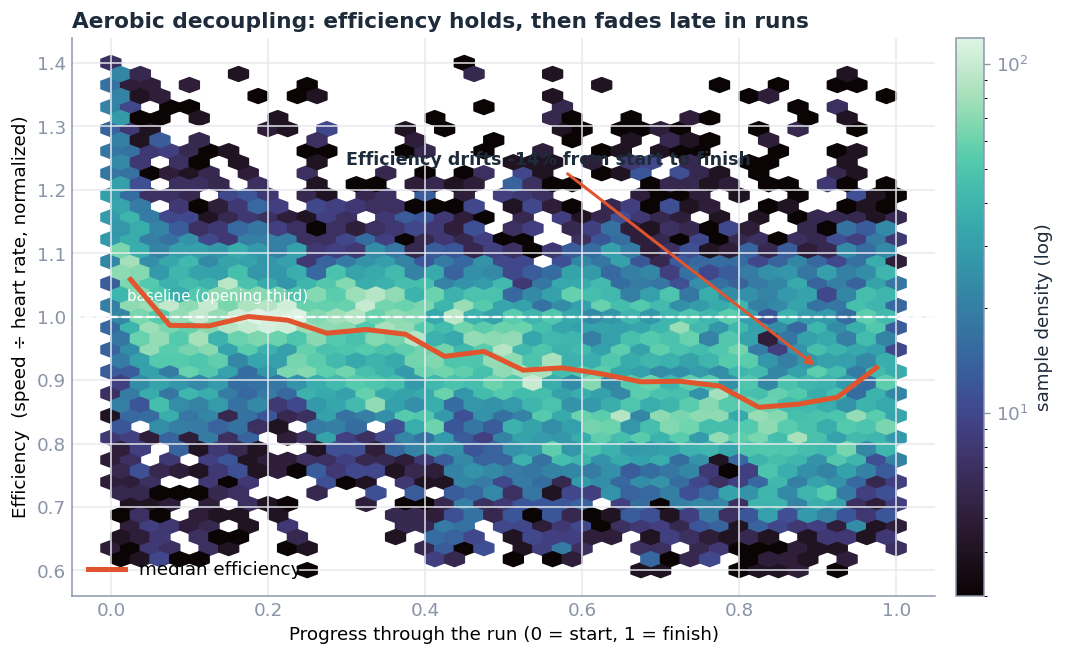

Start-to-finish efficiency drift: -13.9%


In [9]:
d = df[df["heart_rate"].notna() & (df["speed_ms"] > 1.0)].copy()
d["prog"] = d.groupby("datafile")["distance"].transform(lambda x: (x - x.min())/(x.max()-x.min()+1e-9))
d["eff"]  = d["speed_ms"] / d["heart_rate"]            

base = d[d["prog"] <= 0.33].groupby("datafile")["eff"].mean()
d["eff_n"] = d["eff"] / d["datafile"].map(base)
d = d[d["eff_n"].between(0.6, 1.4)]

fig, ax = plt.subplots(figsize=(9.5, 5.6))
hb = ax.hexbin(d["prog"], d["eff_n"], gridsize=40, cmap="mako", mincnt=3, bins="log")
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("sample density (log)", color=INK); cb.ax.tick_params(colors=MUTE)


pb = np.linspace(0, 1, 21); pm = (pb[:-1]+pb[1:])/2
med = [d.loc[(d.prog>=pb[i])&(d.prog<pb[i+1]), "eff_n"].median() for i in range(len(pb)-1)]
ax.plot(pm, med, color=ACCENT, lw=3, zorder=5, label="median efficiency")
ax.axhline(1.0, color="white", ls="--", lw=1.4, alpha=0.9)

drift = (med[-1] - med[0]) * 100
ax.annotate(f"Efficiency drifts {drift:+.0f}% from start to finish",
            xy=(0.9, med[-1]), xytext=(0.30, 1.24),
            color=INK, fontsize=10.5, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.8))
ax.text(0.02, 1.02, "baseline (opening third)", color="white", fontsize=9, va="bottom")
ax.set_xlabel("Progress through the run (0 = start, 1 = finish)")
ax.set_ylabel("Efficiency  (speed ÷ heart rate, normalized)")
ax.set_title("Aerobic decoupling: efficiency holds, then fades late in runs")
ax.legend(frameon=False, loc="lower left")
style_axes(ax); plt.tight_layout(); plt.show()
print(f"Start-to-finish efficiency drift: {drift:+.1f}%")

Insight: The dense core sits right on the baseline for the first ~60% of each run, the athlete holds
efficiency remarkably steady, before the median curve bends downward in the final third. A modest late
decouple like this is the hallmark of good but not elite aerobic durability: fitness is solid, and the
main gain available is extending the point at which efficiency starts to fade.

## 5. A bonus look: the Stryd power subset

Only 10 runs carry running-power data. Rather than force a fragile deep dive, I confirm the physics as a
sanity check: Form Power (energy "wasted" bouncing) should rise with Vertical Oscillation.

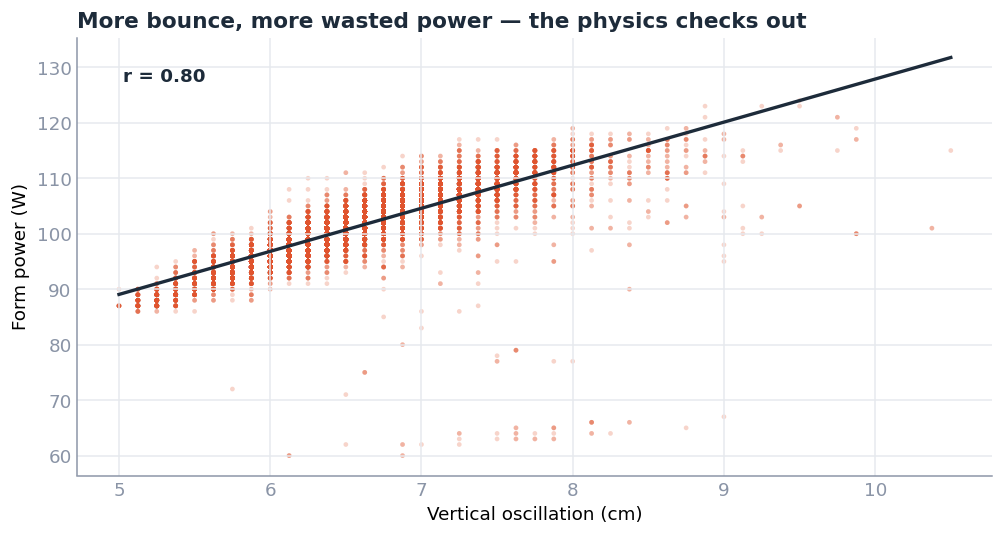

In [10]:
p = df[df["Power"].notna() & df["Vertical Oscillation"].notna()]
p = p[(p["Vertical Oscillation"].between(3, 11)) & (p["Form Power"].between(60, 125))]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(p["Vertical Oscillation"], p["Form Power"], s=8, alpha=0.25,
           color=ACCENT, edgecolors="none")
z = np.polyfit(p["Vertical Oscillation"], p["Form Power"], 1)
xs = np.linspace(p["Vertical Oscillation"].min(), p["Vertical Oscillation"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=INK, lw=2)
r = np.corrcoef(p["Vertical Oscillation"], p["Form Power"])[0,1]
ax.text(0.05, 0.9, f"r = {r:.2f}", transform=ax.transAxes, fontweight="bold", color=INK)
ax.set_xlabel("Vertical oscillation (cm)"); ax.set_ylabel("Form power (W)")
ax.set_title("More bounce, more wasted power — the physics checks out")
style_axes(ax); plt.tight_layout(); plt.show()

Insight. The positive correlation confirms the Stryd data is internally consistent and physically sensible:
runs with more vertical bounce show higher form power (wasted energy). The lesson for the athlete is concrete:
reducing bounce would reclaim watts that could go into forward speed.

## 6. Conclusion

From an unlabeled 40k-row dump, a coherent portrait emerges:

1. Who & where: a night runner in Ann Arbor, MI, training across summer 2019, with ~80% of runs
   starting after 8 pm.
2. How they run: speed comes from stride length, not turnover; cadence stays below the folk-wisdom
   180 spm.
3. Training structure: tight weekday pacing with wide-open weekends, the fingerprint of a real plan
   (easy long runs + occasional hard efforts).
4. Fitness verdict: efficiency is held steady through ~60% of each run then decouples modestly late,
   indicating solid aerobic durability with a clear improvement target.
5. Efficiency lever: where power data exists, less vertical bounce means less wasted power.

Professor Chris Brooks they came for "something interesting" and hopefully can leave with
a busted myth (180 spm), a diagnosis of their endurance durability, and one actionable efficiency tip. All
defensible from the data and reproducible from a clean kernel restart.